In [27]:
# ── 1. Install & Import ──────────────────────────────────────
!pip install kagglehub xgboost lightgbm catboost shap lime imbalanced-learn -q

import kagglehub, os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# DL
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# XAI
import shap
import lime, lime.lime_tabular

print("✅ All libraries imported!")
print(f"TensorFlow : {tf.__version__}")

✅ All libraries imported!
TensorFlow : 2.20.0


In [29]:
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
print(" Dataset path:", path)

for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

 Dataset path: /kaggle/input/datasets/laotse/credit-risk-dataset
/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv


In [30]:
csv_path = os.path.join(path, "credit_risk_dataset.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (32581, 12)

Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [32]:
missing = df.isnull().sum()
print(missing[missing > 0])

person_emp_length     895
loan_int_rate        3116
dtype: int64


In [33]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [34]:
print(df['loan_status'].value_counts())
print(f"Default Rate: {df['loan_status'].mean()*100:.2f}%")

loan_status
0    25473
1     7108
Name: count, dtype: int64
Default Rate: 21.82%


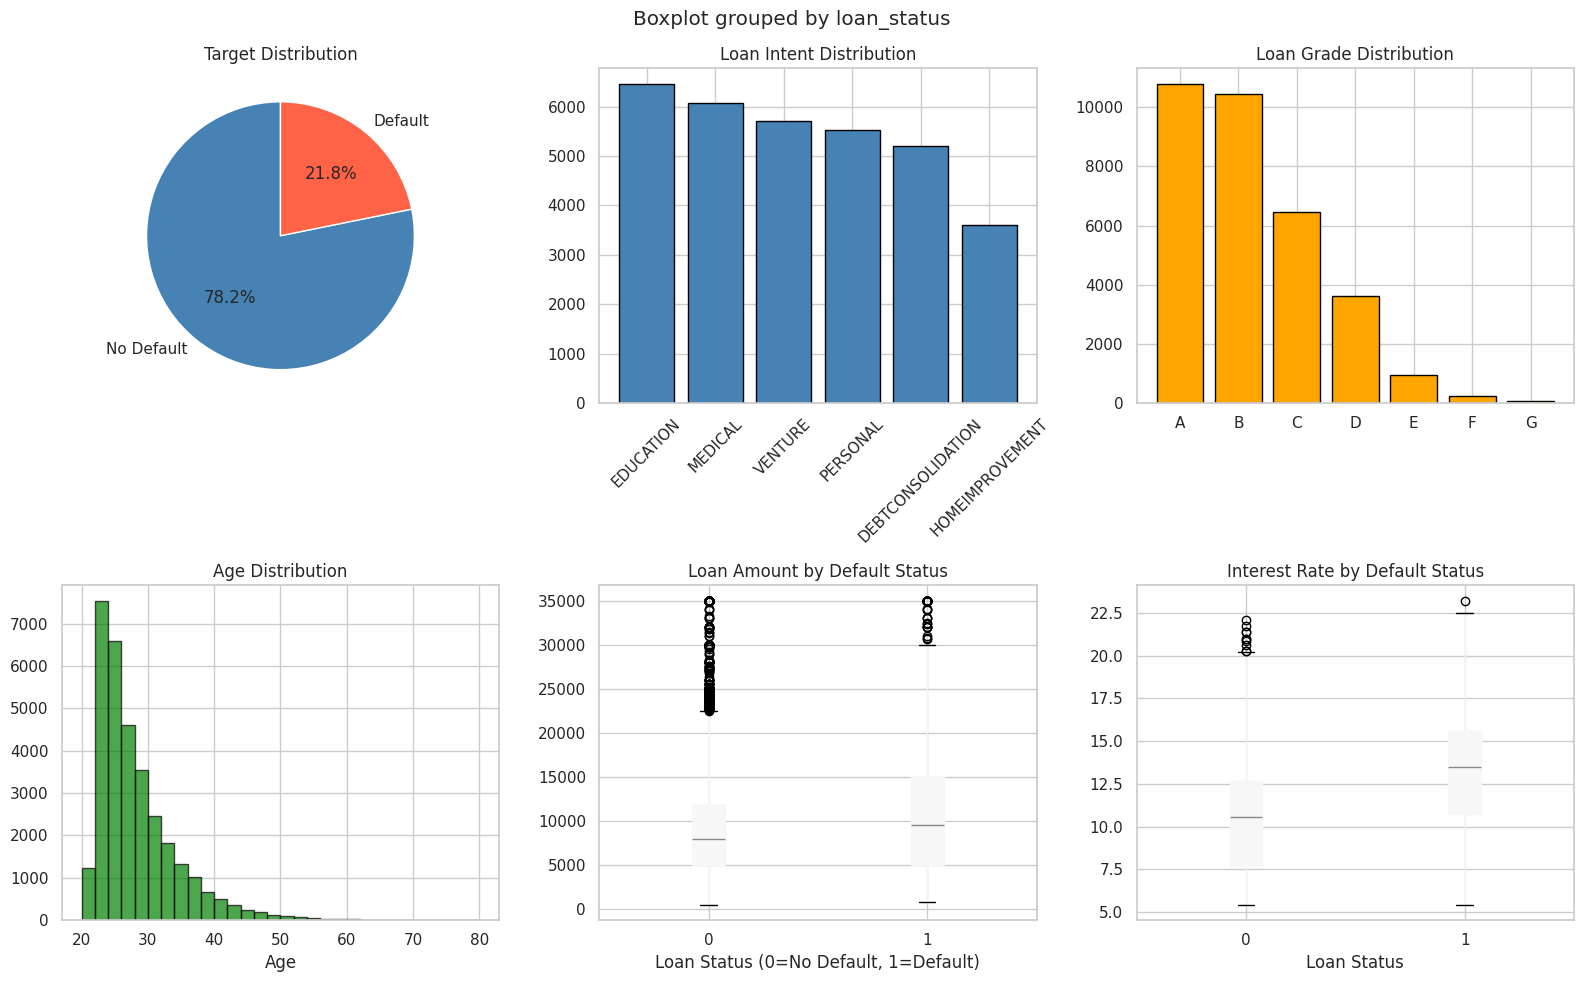

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Loan Default — Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Target distribution
axes[0,0].pie(df['loan_status'].value_counts(),
              labels=['No Default','Default'],
              autopct='%1.1f%%',
              colors=['steelblue','tomato'],
              startangle=90)
axes[0,0].set_title('Target Distribution')

# Loan Intent
intent_counts = df['loan_intent'].value_counts()
axes[0,1].bar(intent_counts.index, intent_counts.values, color='steelblue', edgecolor='black')
axes[0,1].set_title('Loan Intent Distribution')
axes[0,1].tick_params(axis='x', rotation=45)

# Loan Grade
grade_counts = df['loan_grade'].value_counts().sort_index()
axes[0,2].bar(grade_counts.index, grade_counts.values, color='orange', edgecolor='black')
axes[0,2].set_title('Loan Grade Distribution')

# Person Age distribution
axes[1,0].hist(df['person_age'].clip(upper=80), bins=30, color='green', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')

# Loan Amount vs Default
df.boxplot(column='loan_amnt', by='loan_status', ax=axes[1,1],
           notch=False, patch_artist=True)
axes[1,1].set_title('Loan Amount by Default Status')
axes[1,1].set_xlabel('Loan Status (0=No Default, 1=Default)')
plt.sca(axes[1,1])
plt.title('Loan Amount by Default Status')

# Interest Rate vs Default
df.boxplot(column='loan_int_rate', by='loan_status', ax=axes[1,2],
           notch=False, patch_artist=True)
axes[1,2].set_title('Interest Rate by Default Status')
axes[1,2].set_xlabel('Loan Status')
plt.sca(axes[1,2])
plt.title('Interest Rate by Default Status')

plt.tight_layout()
plt.show()

In [36]:
print("Before cleaning shape:", df.shape)

# Age outlier fix (age > 100 unrealistic)
df = df[df['person_age'] <= 100]

# Employment length outlier fix
df = df[df['person_emp_length'] <= 60]

# Missing value imputation
# Numeric — median fill
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"   Filled '{col}' with median")

# Categorical — mode fill
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"   Filled '{col}' with mode")

print("\nAfter cleaning shape:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())

Before cleaning shape: (32581, 12)
   Filled 'loan_int_rate' with median

After cleaning shape: (31679, 12)
Remaining nulls: 0


In [37]:
df_fe = df.copy()

# --- 7a. Ratio Features ---
df_fe['loan_to_income_ratio']     = df_fe['loan_amnt']      / (df_fe['person_income'] + 1)
df_fe['installment_to_income']    = df_fe['loan_amnt']      / (df_fe['person_income'] + 1) * (df_fe['loan_int_rate'] / 100)
df_fe['income_per_emp_year']      = df_fe['person_income']  / (df_fe['person_emp_length'] + 1)
df_fe['loan_age_ratio']           = df_fe['loan_amnt']      / (df_fe['person_age'] + 1)

# --- 7b. Risk Score (rule-based) ---
df_fe['high_int_rate']   = (df_fe['loan_int_rate']       > 15).astype(int)
df_fe['high_loan_pct']   = (df_fe['loan_percent_income'] > 0.3).astype(int)
df_fe['short_history']   = (df_fe['cb_person_cred_hist_length'] < 3).astype(int)
df_fe['risk_score']      = df_fe['high_int_rate'] + df_fe['high_loan_pct'] + df_fe['short_history']

# --- 7c. Encode Categorical ---
cat_cols = df_fe.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_fe[col] = le.fit_transform(df_fe[col].astype(str))

print("\n Feature Engineering Done!")
print("New shape:", df_fe.shape)
df_fe.head(3)

Categorical columns to encode: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

 Feature Engineering Done!
New shape: (31679, 20)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,installment_to_income,income_per_emp_year,loan_age_ratio,high_int_rate,high_loan_pct,short_history,risk_score
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2,0.104156,0.011603,1600.0,45.454545,0,0,1,1
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3,0.572857,0.073727,4800.0,211.538462,0,1,0,1
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2,0.534343,0.081380,13100.0,1458.333333,1,1,1,3


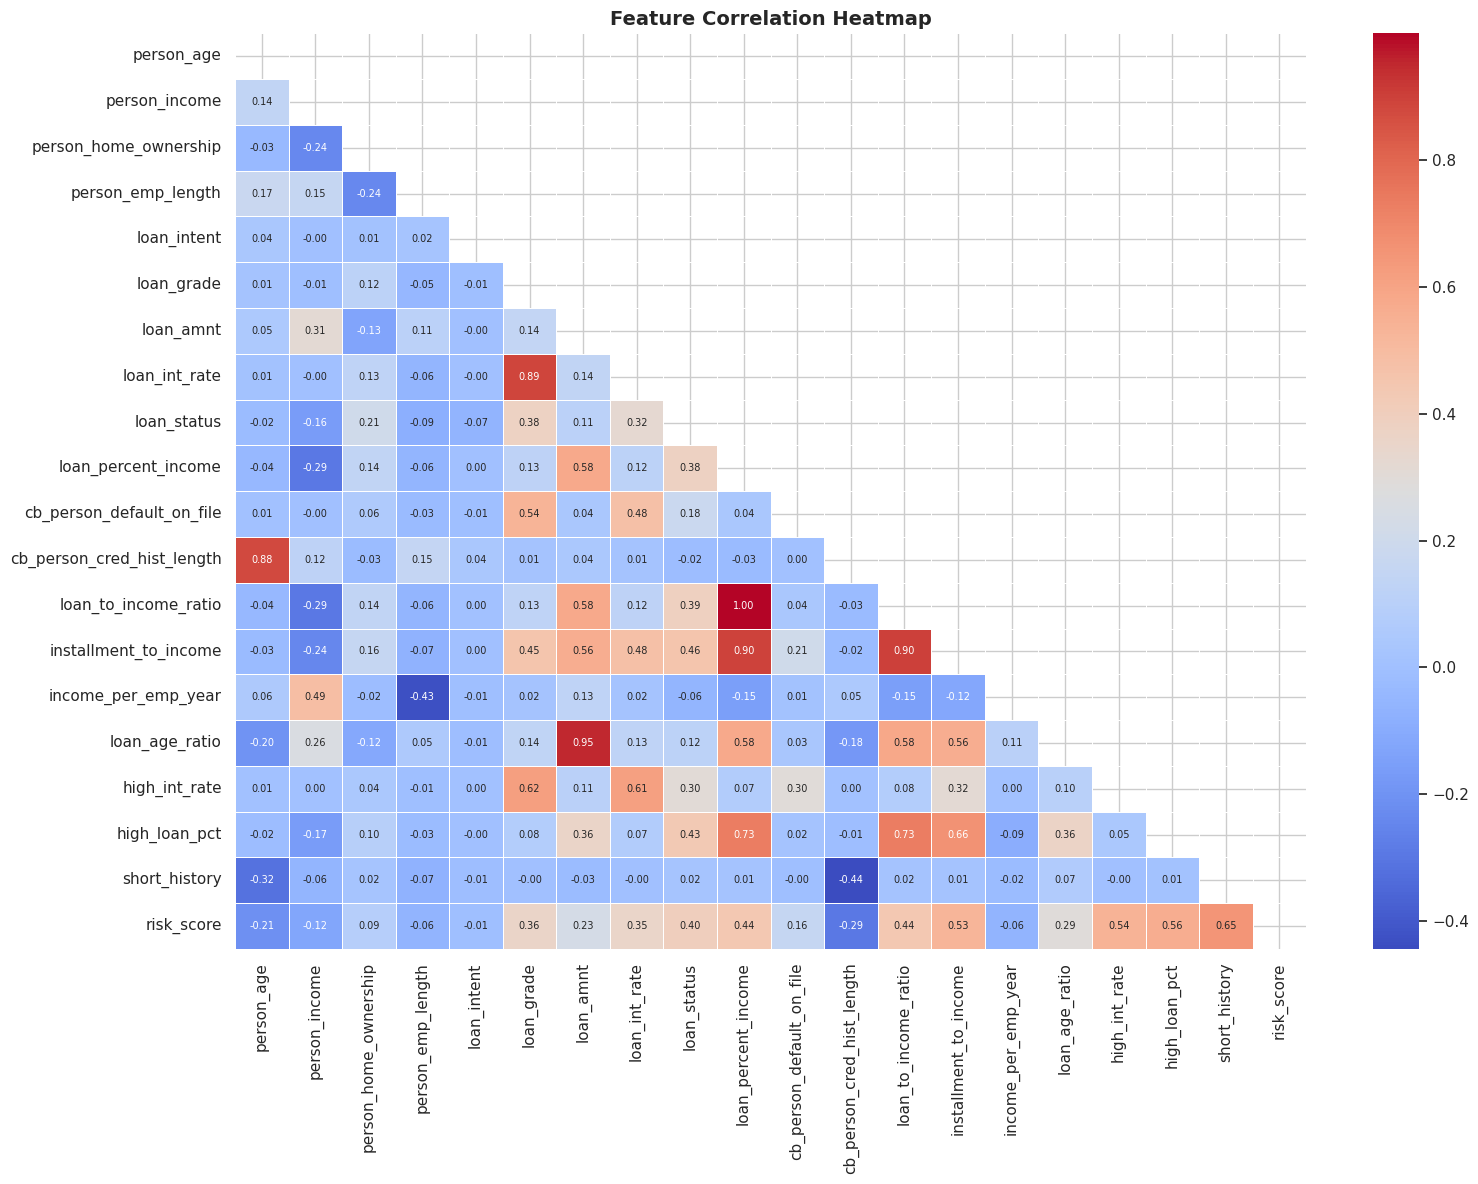


 Top Features Correlated with loan_status:
loan_status                  1.000000
installment_to_income        0.455327
high_loan_pct                0.431394
risk_score                   0.400692
loan_to_income_ratio         0.386543
loan_percent_income          0.379823
loan_grade                   0.376983
loan_int_rate                0.323247
high_int_rate                0.304800
person_home_ownership        0.208801
cb_person_default_on_file    0.181090
person_income                0.164128
loan_age_ratio               0.115202
loan_amnt                    0.112188
person_emp_length            0.085966
Name: loan_status, dtype: float64


In [38]:
plt.figure(figsize=(16, 12))
corr = df_fe.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlated features with target
print("\n Top Features Correlated with loan_status:")
print(corr['loan_status'].abs().sort_values(ascending=False).head(15))

In [39]:
X = df_fe.drop('loan_status', axis=1)
y = df_fe['loan_status']

feature_names = X.columns.tolist()

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"\nClass distribution before SMOTE:\n{y.value_counts()}")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE on train only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f"\nAfter SMOTE:")
print(f"  Train shape : {X_train_sm.shape}")
print(pd.Series(y_train_sm).value_counts())

Features: 19  |  Samples: 31679

Class distribution before SMOTE:
loan_status
0    24854
1     6825
Name: count, dtype: int64

After SMOTE:
  Train shape : (39766, 19)
loan_status
0    19883
1    19883
Name: count, dtype: int64


In [40]:
results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te, is_nn=False):
    if not is_nn:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        try:
            y_prob = model.predict_proba(X_te)[:, 1]
        except:
            y_prob = y_pred.astype(float)
    else:
        y_prob = model.predict(X_te).ravel()
        y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    ap  = average_precision_score(y_te, y_prob)

    results[name] = {'Accuracy': acc, 'ROC-AUC': auc, 'Avg Precision': ap}

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  ROC-AUC       : {auc:.4f}")
    print(f"  Avg Precision : {ap:.4f}")
    print(classification_report(y_te, y_pred,
          target_names=['No Default', 'Default']))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Default','Default'],
                yticklabels=['No Default','Default'])
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    return y_prob


  Logistic Regression
  Accuracy      : 0.8166
  ROC-AUC       : 0.8773
  Avg Precision : 0.7319
              precision    recall  f1-score   support

  No Default       0.93      0.83      0.88      4971
     Default       0.55      0.77      0.64      1365

    accuracy                           0.82      6336
   macro avg       0.74      0.80      0.76      6336
weighted avg       0.85      0.82      0.83      6336



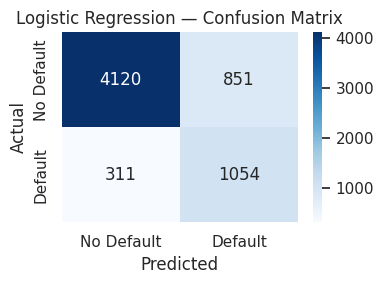

In [41]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_prob = evaluate('Logistic Regression', lr,
                   X_train_sm, X_test_sc, y_train_sm, y_test)


  Decision Tree
  Accuracy      : 0.9167
  ROC-AUC       : 0.9052
  Avg Precision : 0.8472
              precision    recall  f1-score   support

  No Default       0.93      0.97      0.95      4971
     Default       0.86      0.73      0.79      1365

    accuracy                           0.92      6336
   macro avg       0.90      0.85      0.87      6336
weighted avg       0.91      0.92      0.91      6336



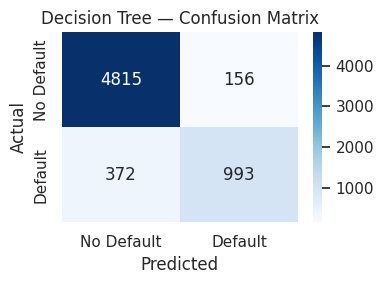

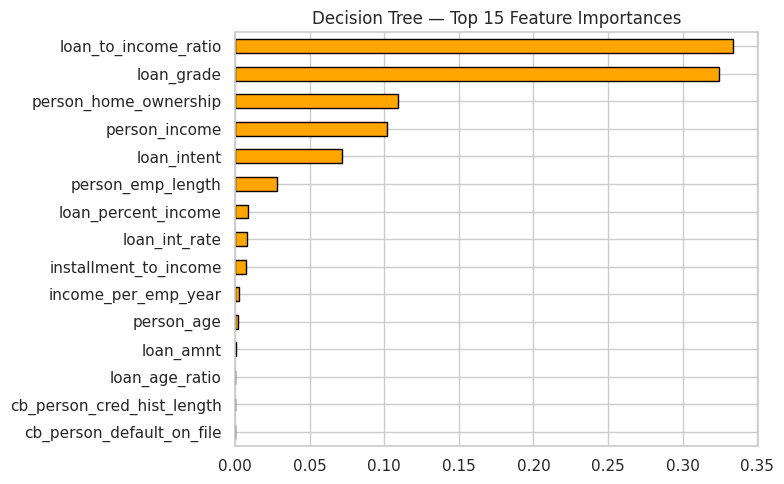

In [42]:
dt = DecisionTreeClassifier(max_depth=8, class_weight='balanced',
                            random_state=42)
dt_prob = evaluate('Decision Tree', dt,
                   X_train_sm, X_test_sc, y_train_sm, y_test)

# Tree Feature Importance
feat_dt = pd.Series(dt.feature_importances_,
                    index=feature_names).sort_values(ascending=False)[:15]
plt.figure(figsize=(8, 5))
feat_dt.plot(kind='barh', color='orange', edgecolor='black')
plt.title('Decision Tree — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


  Random Forest
  Accuracy      : 0.9162
  ROC-AUC       : 0.9276
  Avg Precision : 0.8755
              precision    recall  f1-score   support

  No Default       0.93      0.96      0.95      4971
     Default       0.84      0.75      0.79      1365

    accuracy                           0.92      6336
   macro avg       0.89      0.86      0.87      6336
weighted avg       0.91      0.92      0.91      6336



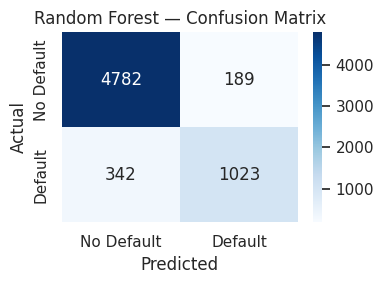

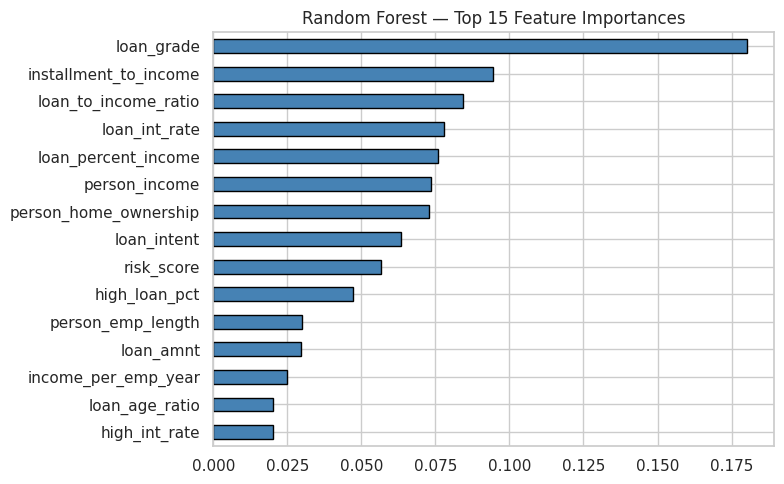

In [43]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                            class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf_prob = evaluate('Random Forest', rf,
                   X_train_sm, X_test_sc, y_train_sm, y_test)

# Feature Importance
feat_rf = pd.Series(rf.feature_importances_,
                    index=feature_names).sort_values(ascending=False)[:15]
plt.figure(figsize=(8, 5))
feat_rf.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Random Forest — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


  XGBoost
  Accuracy      : 0.9373
  ROC-AUC       : 0.9399
  Avg Precision : 0.8937
              precision    recall  f1-score   support

  No Default       0.93      0.99      0.96      4971
     Default       0.97      0.74      0.83      1365

    accuracy                           0.94      6336
   macro avg       0.95      0.86      0.90      6336
weighted avg       0.94      0.94      0.93      6336



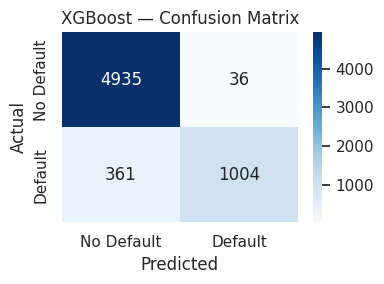

In [44]:
scale_pos = int((y_train_sm == 0).sum() / (y_train_sm == 1).sum())

xgb = XGBClassifier(n_estimators=300, learning_rate=0.05,
                    max_depth=5, subsample=0.8,
                    colsample_bytree=0.8,
                    use_label_encoder=False,
                    eval_metric='logloss',
                    random_state=42, n_jobs=-1)
xgb_prob = evaluate('XGBoost', xgb,
                    X_train_sm, X_test_sc, y_train_sm, y_test)


  LightGBM
  Accuracy      : 0.9358
  ROC-AUC       : 0.9388
  Avg Precision : 0.8913
              precision    recall  f1-score   support

  No Default       0.93      0.99      0.96      4971
     Default       0.96      0.73      0.83      1365

    accuracy                           0.94      6336
   macro avg       0.95      0.86      0.90      6336
weighted avg       0.94      0.94      0.93      6336



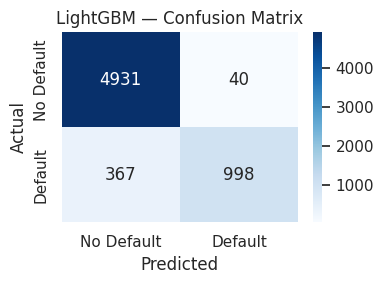

In [45]:
lgb = LGBMClassifier(n_estimators=300, learning_rate=0.05,
                     max_depth=5, num_leaves=31,
                     class_weight='balanced',
                     random_state=42, verbose=-1, n_jobs=-1)
lgb_prob = evaluate('LightGBM', lgb,
                    X_train_sm, X_test_sc, y_train_sm, y_test)


  CatBoost
  Accuracy      : 0.9373
  ROC-AUC       : 0.9371
  Avg Precision : 0.8895
              precision    recall  f1-score   support

  No Default       0.93      0.99      0.96      4971
     Default       0.98      0.73      0.83      1365

    accuracy                           0.94      6336
   macro avg       0.95      0.86      0.90      6336
weighted avg       0.94      0.94      0.93      6336



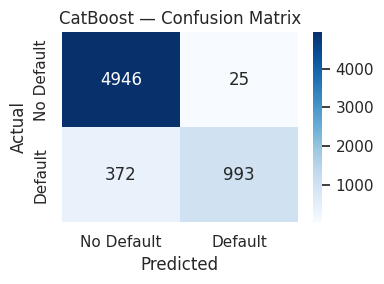

In [46]:
cb = CatBoostClassifier(iterations=300, learning_rate=0.05,
                        depth=5, auto_class_weights='Balanced',
                        random_state=42, verbose=0)
cb_prob = evaluate('CatBoost', cb,
                   X_train_sm, X_test_sc, y_train_sm, y_test)

I0000 00:00:1783260947.254347      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783260947.257145      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1783260951.845071     423 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


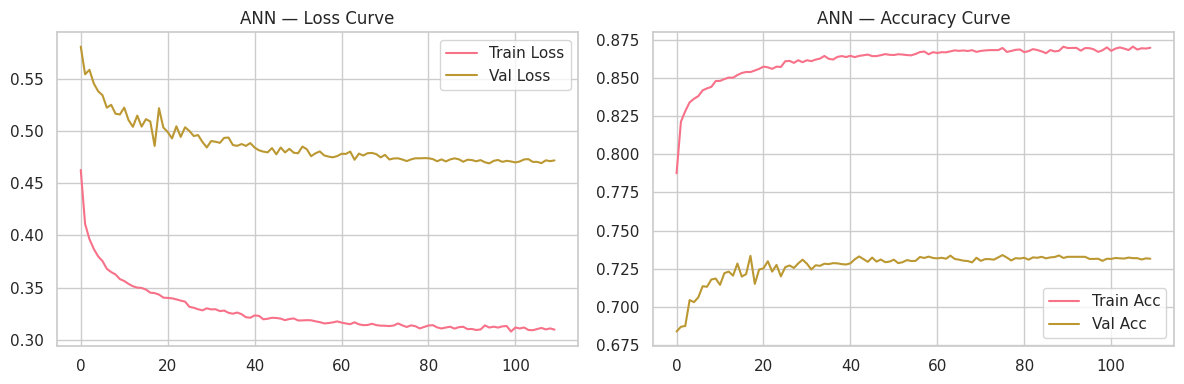

198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

  ANN
  Accuracy      : 0.9085
  ROC-AUC       : 0.9163
  Avg Precision : 0.8568
              precision    recall  f1-score   support

  No Default       0.93      0.96      0.94      4971
     Default       0.83      0.73      0.77      1365

    accuracy                           0.91      6336
   macro avg       0.88      0.84      0.86      6336
weighted avg       0.91      0.91      0.91      6336



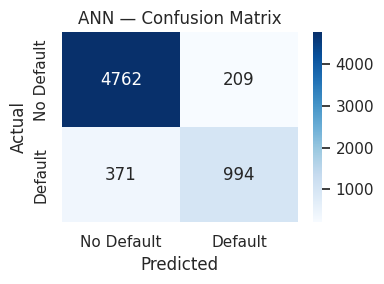

In [47]:
def build_ann(input_dim):
    model = Sequential([
        Dense(64,  activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(32,  activation='relu'),
        Dropout(0.2),
        Dense(1,   activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

ann = build_ann(X_train_sm.shape[1])
ann.summary()

es1 = EarlyStopping(patience=15, restore_best_weights=True, verbose=0)
rl1 = ReduceLROnPlateau(patience=7, factor=0.5, verbose=0)

h_ann = ann.fit(X_train_sm, y_train_sm,
                validation_split=0.2,
                epochs=150, batch_size=64,
                callbacks=[es1, rl1], verbose=0)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_ann.history['loss'],     label='Train Loss')
axes[0].plot(h_ann.history['val_loss'], label='Val Loss')
axes[0].set_title('ANN — Loss Curve'); axes[0].legend()

axes[1].plot(h_ann.history['accuracy'],     label='Train Acc')
axes[1].plot(h_ann.history['val_accuracy'], label='Val Acc')
axes[1].set_title('ANN — Accuracy Curve'); axes[1].legend()
plt.tight_layout(); plt.show()

ann_prob = evaluate('ANN', ann,
                    X_train_sm, X_test_sc, y_train_sm, y_test,
                    is_nn=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,673 (737.00 KB)

 Trainable params: 186,753 (729.50 KB)

 Non-trainable params: 1,920 (7.50 KB)

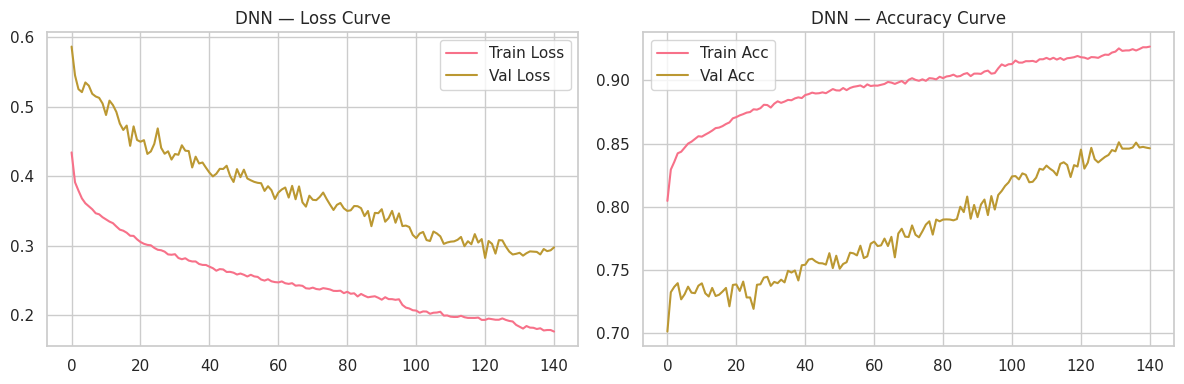

198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

  DNN
  Accuracy      : 0.9154
  ROC-AUC       : 0.9214
  Avg Precision : 0.8704
              precision    recall  f1-score   support

  No Default       0.93      0.96      0.95      4971
     Default       0.84      0.76      0.79      1365

    accuracy                           0.92      6336
   macro avg       0.89      0.86      0.87      6336
weighted avg       0.91      0.92      0.91      6336



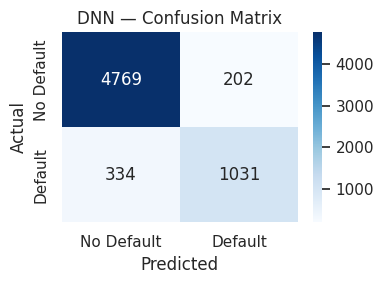

In [48]:
def build_dnn(input_dim):
    model = Sequential([
        Dense(512,  activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.4),

        Dense(256,  activation='relu'),
        BatchNormalization(),
        Dropout(0.35),

        Dense(128,  activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64,   activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32,   activation='relu'),
        Dense(1,    activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

dnn = build_dnn(X_train_sm.shape[1])
dnn.summary()

es2 = EarlyStopping(patience=20, restore_best_weights=True, verbose=0)
rl2 = ReduceLROnPlateau(patience=8, factor=0.5, verbose=0)

h_dnn = dnn.fit(X_train_sm, y_train_sm,
                validation_split=0.2,
                epochs=200, batch_size=64,
                callbacks=[es2, rl2], verbose=0)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_dnn.history['loss'],     label='Train Loss')
axes[0].plot(h_dnn.history['val_loss'], label='Val Loss')
axes[0].set_title('DNN — Loss Curve'); axes[0].legend()

axes[1].plot(h_dnn.history['accuracy'],     label='Train Acc')
axes[1].plot(h_dnn.history['val_accuracy'], label='Val Acc')
axes[1].set_title('DNN — Accuracy Curve'); axes[1].legend()
plt.tight_layout(); plt.show()

dnn_prob = evaluate('DNN', dnn,
                    X_train_sm, X_test_sc, y_train_sm, y_test,
                    is_nn=True)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:22:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  Voting Ensemble (ML)
  Accuracy      : 0.9315
  ROC-AUC       : 0.9328
  Avg Precision : 0.8864
              precision    recall  f1-score   support

  No Default       0.93      0.98      0.96      4971
     Default       0.93      0.74      0.82      1365

    accuracy                           0.93      6336
   macro avg       0.93      0.86      0.89      6336
weighted avg       0.93      0.93      0.93      6336



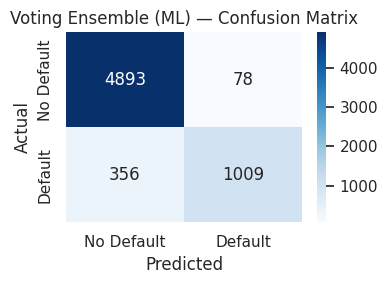


  Hybrid Weighted Ensemble (XGB+LGB+CB+DNN+RF)
  Accuracy      : 0.9372
  ROC-AUC       : 0.9393
  Avg Precision : 0.8931
              precision    recall  f1-score   support

  No Default       0.93      0.99      0.96      4971
     Default       0.97      0.73      0.83      1365

    accuracy                           0.94      6336
   macro avg       0.95      0.86      0.90      6336
weighted avg       0.94      0.94      0.93      6336



In [49]:
voting = VotingClassifier(
    estimators=[
        ('lr',  lr),
        ('dt',  dt),
        ('rf',  rf),
        ('xgb', xgb),
        ('lgb', lgb),
        ('cb',  cb)
    ],
    voting='soft', n_jobs=-1
)
voting_prob = evaluate('Voting Ensemble (ML)', voting,
                       X_train_sm, X_test_sc, y_train_sm, y_test)

# --- 19b. Weighted Average Ensemble (ML + DNN) ---
# Best ML models get higher weight
weighted_prob = (xgb_prob * 0.25 +
                 lgb_prob * 0.25 +
                 cb_prob  * 0.20 +
                 dnn_prob * 0.20 +
                 rf_prob  * 0.10)

weighted_pred = (weighted_prob > 0.5).astype(int)

acc = accuracy_score(y_test, weighted_pred)
auc = roc_auc_score(y_test, weighted_prob)
ap  = average_precision_score(y_test, weighted_prob)

results['Hybrid Weighted Ensemble'] = {
    'Accuracy': acc, 'ROC-AUC': auc, 'Avg Precision': ap
}

print(f"\n{'='*55}")
print("  Hybrid Weighted Ensemble (XGB+LGB+CB+DNN+RF)")
print(f"{'='*55}")
print(f"  Accuracy      : {acc:.4f}")
print(f"  ROC-AUC       : {auc:.4f}")
print(f"  Avg Precision : {ap:.4f}")
print(classification_report(y_test, weighted_pred,
      target_names=['No Default','Default']))

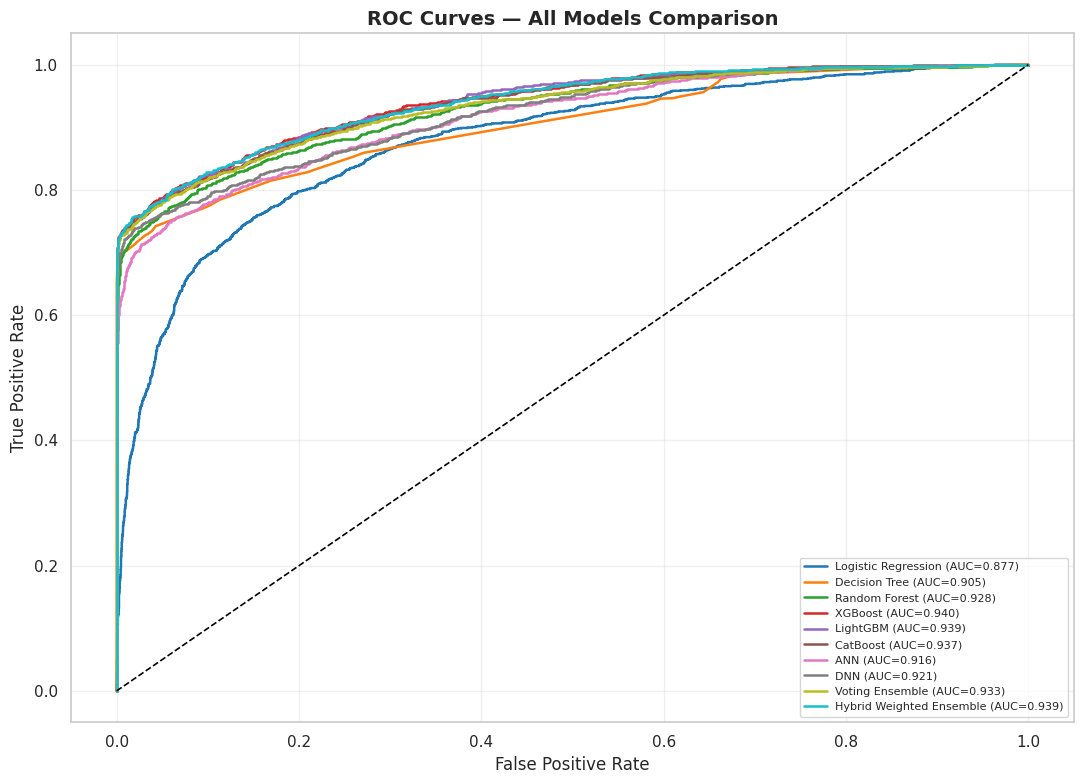

In [50]:
all_probs = {
    'Logistic Regression'     : lr_prob,
    'Decision Tree'           : dt_prob,
    'Random Forest'           : rf_prob,
    'XGBoost'                 : xgb_prob,
    'LightGBM'                : lgb_prob,
    'CatBoost'                : cb_prob,
    'ANN'                     : ann_prob,
    'DNN'                     : dnn_prob,
    'Voting Ensemble'         : voting_prob,
    'Hybrid Weighted Ensemble': weighted_prob,
}

plt.figure(figsize=(11, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_probs)))

for (name, prob), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=1.8)

plt.plot([0,1],[0,1], 'k--', lw=1.2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

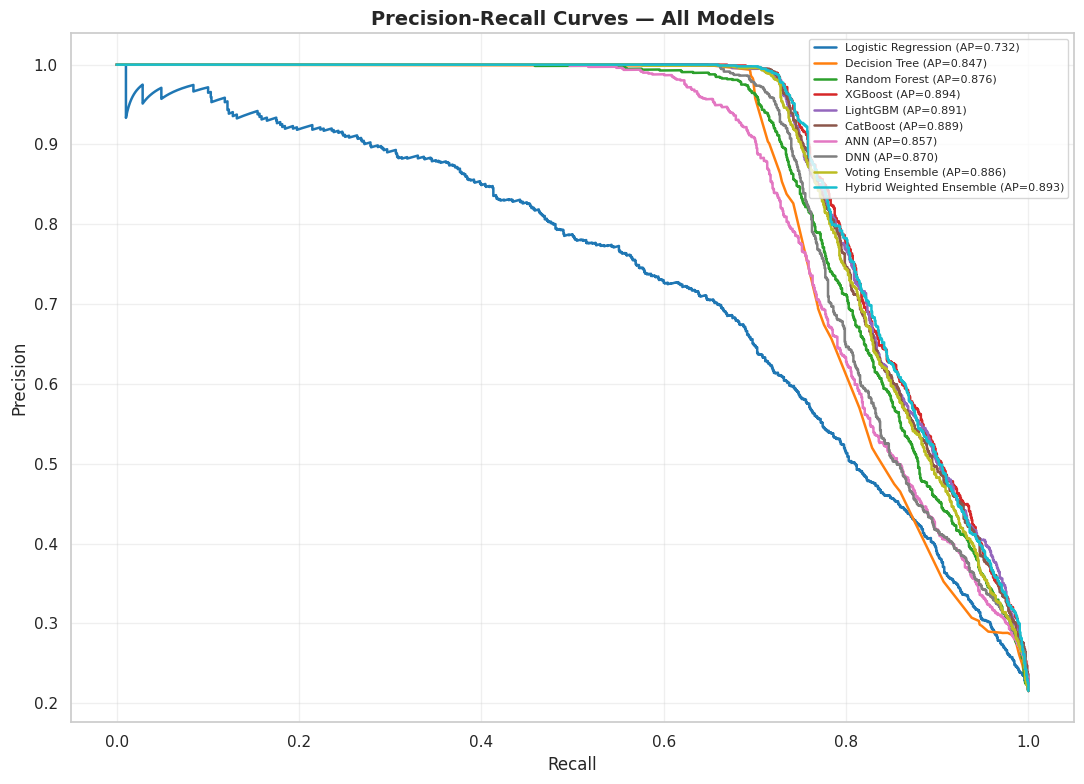

In [51]:
plt.figure(figsize=(11, 8))

for (name, prob), color in zip(all_probs.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, lw=1.8)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


📊 Full Model Performance Comparison:
                          Accuracy   ROC-AUC  Avg Precision
XGBoost                   0.937342  0.939904       0.893688
Hybrid Weighted Ensemble  0.937184  0.939344       0.893123
LightGBM                  0.935764  0.938826       0.891270
CatBoost                  0.937342  0.937097       0.889489
Voting Ensemble (ML)      0.931503  0.932835       0.886410
Random Forest             0.916193  0.927636       0.875537
DNN                       0.915404  0.921446       0.870367
ANN                       0.908460  0.916280       0.856783
Decision Tree             0.916667  0.905214       0.847238
Logistic Regression       0.816604  0.877343       0.731858


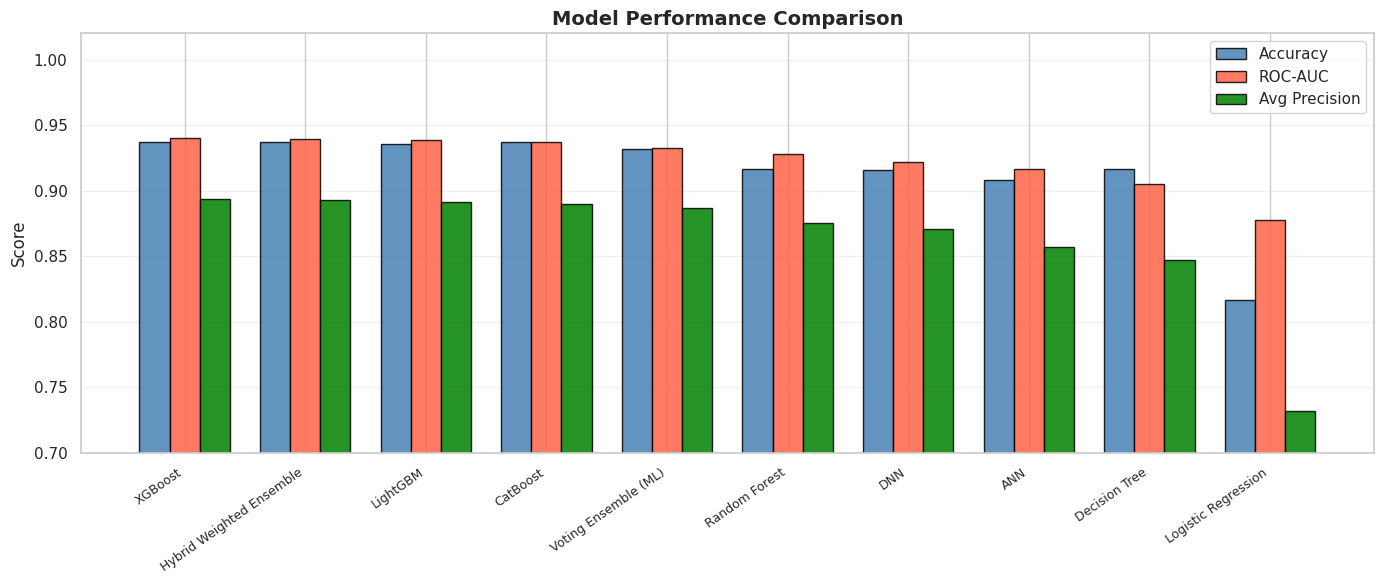

In [52]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)

print("\n Full Model Performance Comparison:")
print("="*65)
print(results_df.to_string())

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x    = np.arange(len(results_df))
w    = 0.25
cols = ['Accuracy', 'ROC-AUC', 'Avg Precision']
clrs = ['steelblue', 'tomato', 'green']

for i, (col, clr) in enumerate(zip(cols, clrs)):
    ax.bar(x + i*w, results_df[col], width=w, label=col,
           color=clr, edgecolor='black', alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(results_df.index, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0.70, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

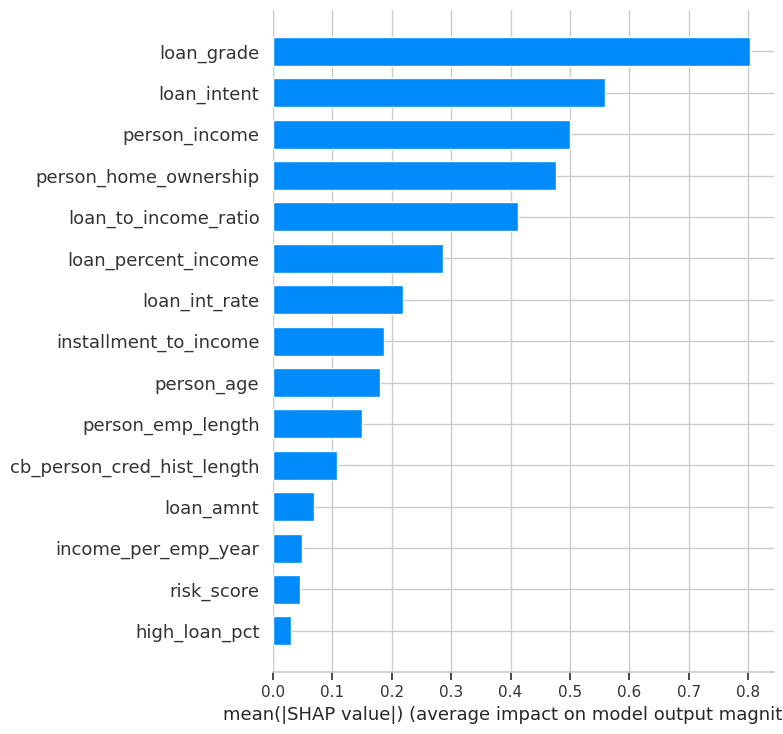

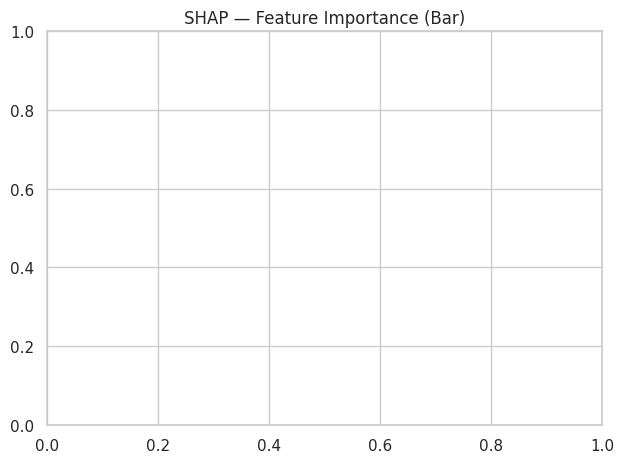

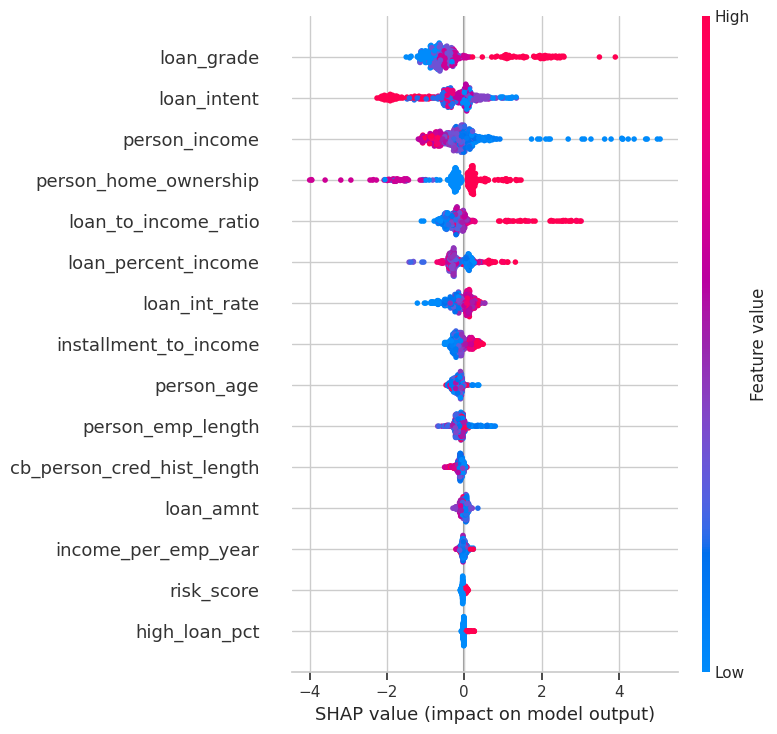

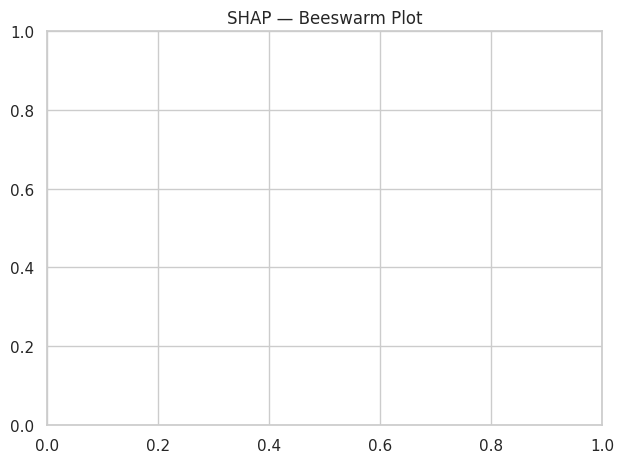

<Figure size 700x500 with 0 Axes>

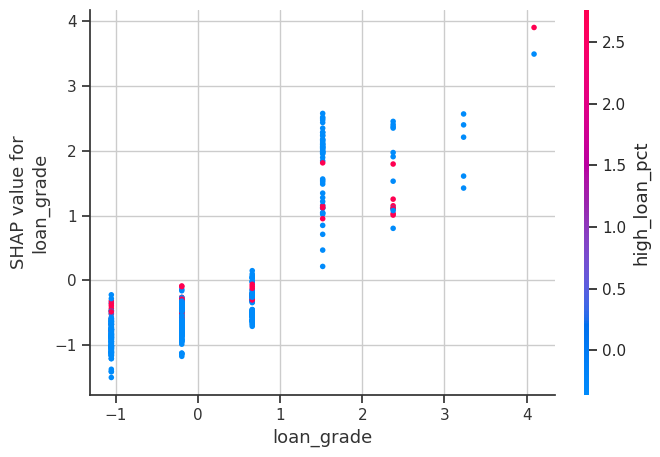

<Figure size 640x480 with 0 Axes>

In [53]:
explainer = shap.TreeExplainer(xgb)
shap_vals  = explainer.shap_values(X_test_sc[:500])   # 500 samples for speed

X_test_df  = pd.DataFrame(X_test_sc[:500], columns=feature_names)

# --- 23a. Bar summary ---
plt.figure()
shap.summary_plot(shap_vals, X_test_df,
                  plot_type='bar', max_display=15, show=True)
plt.title('SHAP — Feature Importance (Bar)')
plt.tight_layout(); plt.show()

# --- 23b. Beeswarm ---
plt.figure()
shap.summary_plot(shap_vals, X_test_df,
                  max_display=15, show=True)
plt.title('SHAP — Beeswarm Plot')
plt.tight_layout(); plt.show()

# --- 23c. Dependence plot (top feature) ---
top_feat = pd.DataFrame(X_test_sc[:500],
                        columns=feature_names).columns[
    np.abs(shap_vals).mean(0).argmax()]

plt.figure(figsize=(7, 5))
shap.dependence_plot(top_feat, shap_vals, X_test_df,
                     show=True)
plt.tight_layout(); plt.show()

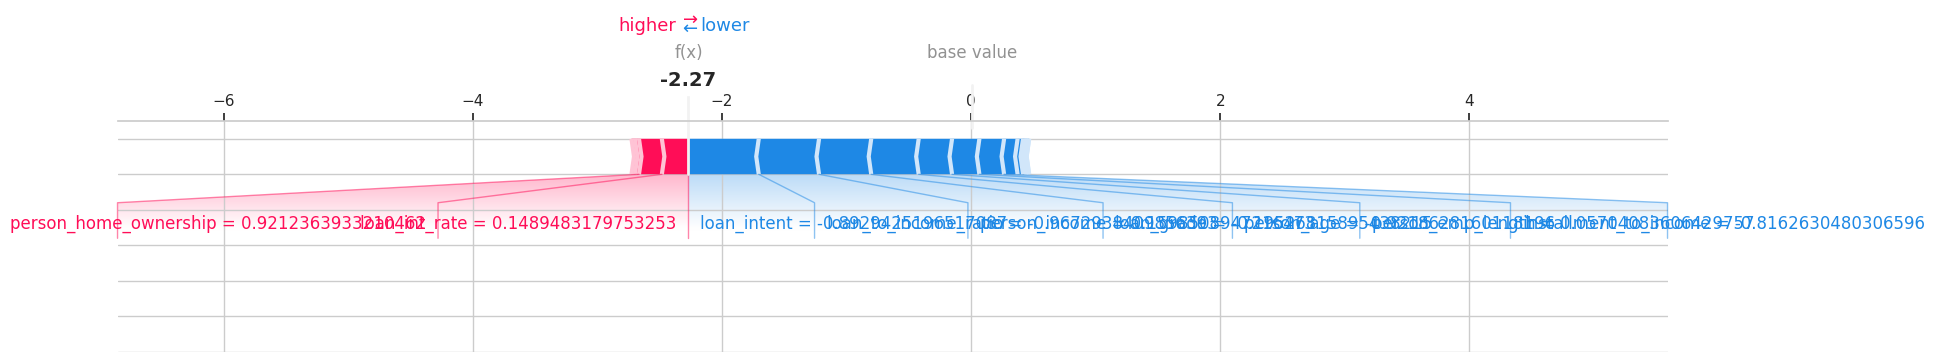

<Figure size 640x480 with 0 Axes>


 SHAP Waterfall Plot — Sample 0


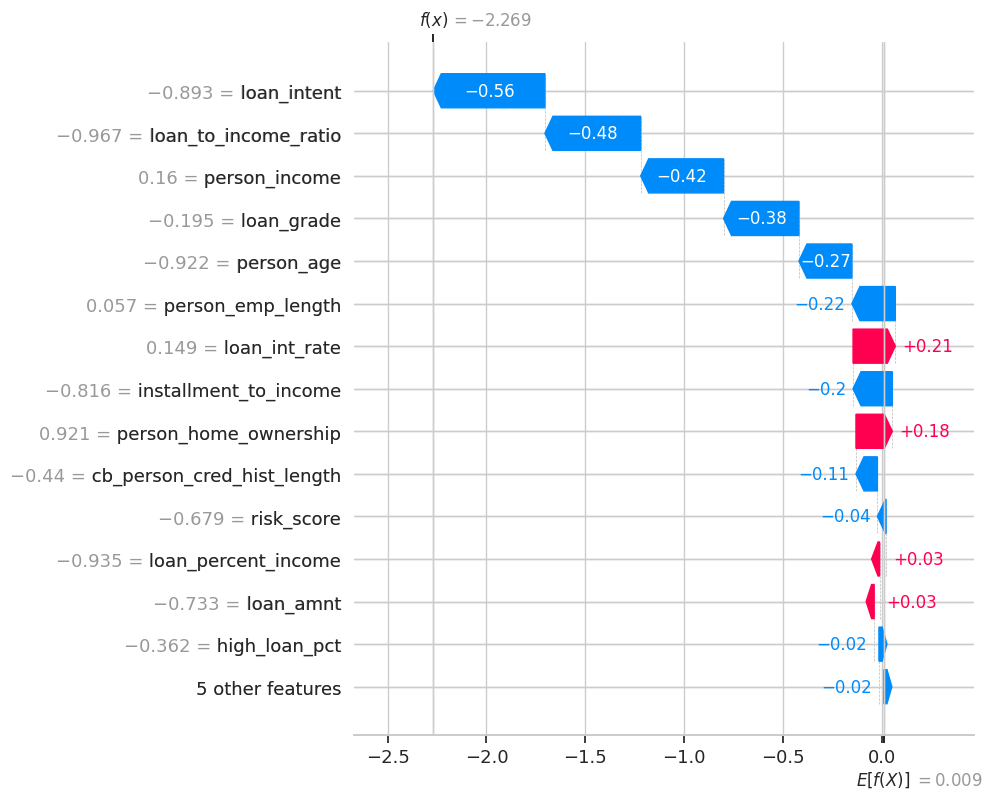

<Figure size 640x480 with 0 Axes>

In [54]:
shap.initjs()
shap.force_plot(explainer.expected_value,
                shap_vals[0],
                X_test_df.iloc[0],
                matplotlib=True)
plt.tight_layout(); plt.show()

# --- 23e. SHAP Waterfall Plot (single sample) ---
print("\n SHAP Waterfall Plot — Sample 0")
shap_explanation = shap.Explanation(
    values        = shap_vals[0],
    base_values   = explainer.expected_value,
    data          = X_test_df.iloc[0].values,
    feature_names = feature_names
)
shap.waterfall_plot(shap_explanation, max_display=15)
plt.tight_layout(); plt.show()


 Default Case (idx=7)
   True     : Default
   Predicted: Default


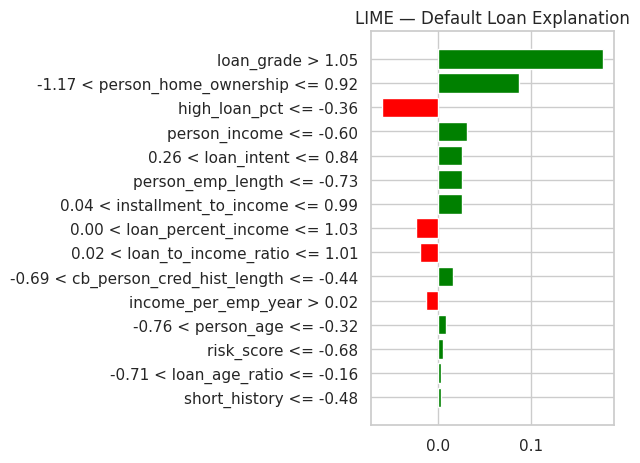


 No-Default Case (idx=0)
   True     : No Default
   Predicted: No Default


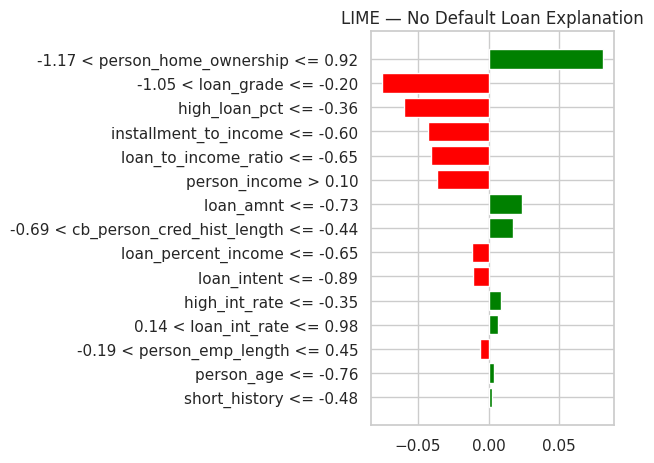

In [55]:
lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_sm,
    feature_names = feature_names,
    class_names   = ['No Default', 'Default'],
    mode          = 'classification',
    random_state  = 42
)

# --- 24a. Default case explanation ---
default_idx = np.where(y_test.values == 1)[0][0]
exp_default = lime_exp.explain_instance(
    data_row   = X_test_sc[default_idx],
    predict_fn = rf.predict_proba,
    num_features = 15
)
print(f"\n Default Case (idx={default_idx})")
print(f"   True     : Default")
print(f"   Predicted: {'Default' if rf.predict(X_test_sc[default_idx:default_idx+1])[0]==1 else 'No Default'}")
exp_default.as_pyplot_figure()
plt.title('LIME — Default Loan Explanation')
plt.tight_layout(); plt.show()

# --- 24b. No-Default case explanation ---
no_default_idx = np.where(y_test.values == 0)[0][0]
exp_nodefault  = lime_exp.explain_instance(
    data_row   = X_test_sc[no_default_idx],
    predict_fn = rf.predict_proba,
    num_features = 15
)
print(f"\n No-Default Case (idx={no_default_idx})")
print(f"   True     : No Default")
print(f"   Predicted: {'Default' if rf.predict(X_test_sc[no_default_idx:no_default_idx+1])[0]==1 else 'No Default'}")
exp_nodefault.as_pyplot_figure()
plt.title('LIME — No Default Loan Explanation')
plt.tight_layout(); plt.show()

📊 5-Fold Cross-Validation (ROC-AUC on SMOTE train):
  Logistic Regression        0.8769 ± 0.0031
  Decision Tree              0.9272 ± 0.0172
  Random Forest              0.9645 ± 0.0140


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  XGBoost                    0.9804 ± 0.0247


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM                   0.9799 ± 0.0266


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CatBoost                   0.9783 ± 0.0273


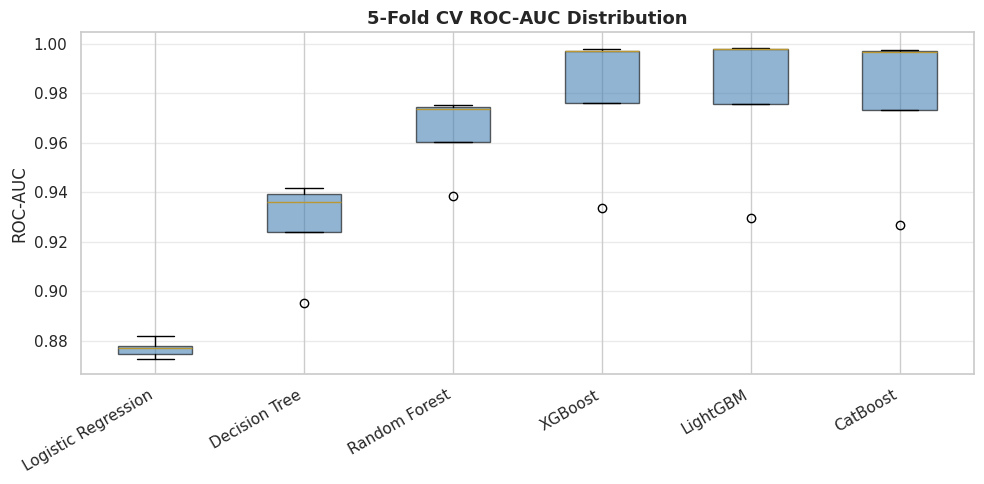

In [56]:
cv_models = {
    'Logistic Regression' : lr,
    'Decision Tree'       : dt,
    'Random Forest'       : rf,
    'XGBoost'             : xgb,
    'LightGBM'            : lgb,
    'CatBoost'            : cb,
}

print("📊 5-Fold Cross-Validation (ROC-AUC on SMOTE train):")
print("="*50)
cv_results = {}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_sm, y_train_sm,
                             cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<25}  {scores.mean():.4f} ± {scores.std():.4f}")

# CV box plot
plt.figure(figsize=(10, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(),
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
plt.xticks(rotation=30, ha='right')
plt.ylabel('ROC-AUC')
plt.title('5-Fold CV ROC-AUC Distribution', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()


Risk Band Summary:
                Count  Actual_Default  Avg_Prob  Default_Rate_%
Risk_Band                                                      
Low Risk         4418             195  0.079155            4.41
Medium Risk       878             166  0.283773           18.91
High Risk          69              38  0.596179           55.07
Very High Risk    971             966  0.954739           99.49


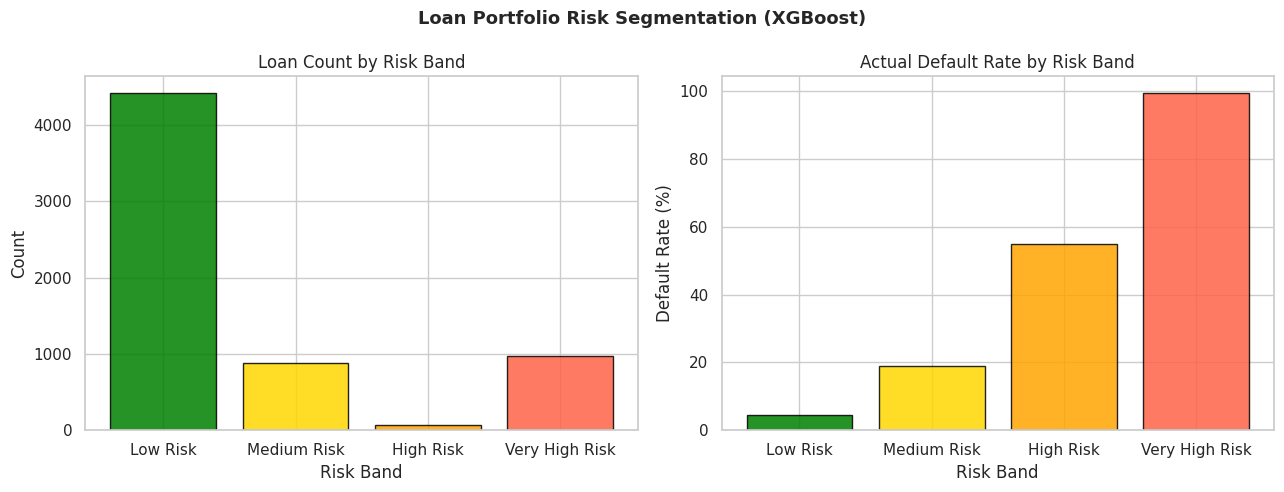

In [57]:
# Use best model (XGBoost) probabilities on full test set
risk_df = pd.DataFrame({
    'Default_Prob' : xgb_prob,
    'Actual'       : y_test.values
})

# Segment by risk band
def risk_band(p):
    if   p < 0.20: return 'Low Risk'
    elif p < 0.50: return 'Medium Risk'
    elif p < 0.75: return 'High Risk'
    else          : return 'Very High Risk'

risk_df['Risk_Band'] = risk_df['Default_Prob'].apply(risk_band)

band_order  = ['Low Risk','Medium Risk','High Risk','Very High Risk']
band_colors = ['green','gold','orange','tomato']

band_summary = risk_df.groupby('Risk_Band').agg(
    Count         = ('Actual','count'),
    Actual_Default= ('Actual','sum'),
    Avg_Prob      = ('Default_Prob','mean')
).reindex(band_order)
band_summary['Default_Rate_%'] = (
    band_summary['Actual_Default'] / band_summary['Count'] * 100
).round(2)

print("\nRisk Band Summary:")
print(band_summary.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(band_order, band_summary['Count'],
            color=band_colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Loan Count by Risk Band')
axes[0].set_xlabel('Risk Band'); axes[0].set_ylabel('Count')

axes[1].bar(band_order, band_summary['Default_Rate_%'],
            color=band_colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Actual Default Rate by Risk Band')
axes[1].set_xlabel('Risk Band'); axes[1].set_ylabel('Default Rate (%)')

plt.suptitle('Loan Portfolio Risk Segmentation (XGBoost)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [58]:
final_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(final_df.to_string())

print("\n" + "-"*65)
print(f"   Best ROC-AUC  : {final_df['ROC-AUC'].idxmax()}  "
      f"({final_df['ROC-AUC'].max():.4f})")
print(f"   Best Accuracy : {final_df['Accuracy'].idxmax()}  "
      f"({final_df['Accuracy'].max():.4f})")
print(f"   Best Avg-Prec : {final_df['Avg Precision'].idxmax()}  "
      f"({final_df['Avg Precision'].max():.4f})")

                          Accuracy   ROC-AUC  Avg Precision
XGBoost                   0.937342  0.939904       0.893688
Hybrid Weighted Ensemble  0.937184  0.939344       0.893123
LightGBM                  0.935764  0.938826       0.891270
CatBoost                  0.937342  0.937097       0.889489
Voting Ensemble (ML)      0.931503  0.932835       0.886410
Random Forest             0.916193  0.927636       0.875537
DNN                       0.915404  0.921446       0.870367
ANN                       0.908460  0.916280       0.856783
Decision Tree             0.916667  0.905214       0.847238
Logistic Regression       0.816604  0.877343       0.731858

-----------------------------------------------------------------
  🥇 Best ROC-AUC  : XGBoost  (0.9399)
  🥇 Best Accuracy : XGBoost  (0.9373)
  🥇 Best Avg-Prec : XGBoost  (0.8937)
